In [1]:
# CELL 1: INSTALL DEPENDENCIES
# ============================================================

!pip install -q pyspark kafka-python streamlit pyngrok pandas numpy scikit-learn plotly

print("✅ Dependencies installed")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.1/326.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 92.4 MB/s eta 0:00:00
✅ Dependencies installed


In [2]:
import pandas as pd
import numpy as np
import sqlite3
import json
import time
import threading
import queue
from datetime import datetime, timedelta
import random
import warnings
warnings.filterwarnings('ignore')

# PySpark for streaming
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, udf, lit, current_timestamp, window
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, TimestampType, IntegerType

# ML
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Visualization
import plotly.express as px
import plotly.graph_objects as go

print("✅ Libraries imported")


✅ Libraries imported


In [3]:
# Configuration
CONFIG = {
    'db_path': '/content/fraud_detection.db',
    'csv_output': '/content/fraud_alerts_output.csv',
    'simulation_speed': 0.1,  # seconds between transactions
    'anomaly_threshold': -0.3,  # Isolation Forest threshold
    'velocity_window_minutes': 5,
    'velocity_threshold': 3,  # max transactions in window
    'amount_threshold': 5000,  # high amount threshold
}

# Initialize SQLite Database
def init_database():
    conn = sqlite3.connect(CONFIG['db_path'])
    cursor = conn.cursor()

    # Flagged transactions table
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS flagged_transactions (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            transaction_id TEXT UNIQUE,
            timestamp TEXT,
            user_id TEXT,
            amount REAL,
            merchant_category TEXT,
            latitude REAL,
            longitude REAL,
            velocity_count INTEGER,
            is_amount_anomaly INTEGER,
            is_geo_anomaly INTEGER,
            ml_score REAL,
            risk_level TEXT,
            flag_reasons TEXT,
            created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
        )
    ''')

    # Audit log table
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS audit_log (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            event_type TEXT,
            event_details TEXT,
            timestamp TIMESTAMP DEFAULT CURRENT_TIMESTAMP
        )
    ''')

    conn.commit()
    conn.close()
    print("✅ Database initialized at", CONFIG['db_path'])

init_database()

✅ Database initialized at /content/fraud_detection.db


In [5]:
class TransactionSimulator:
    """
    Generates realistic synthetic transaction streams with fraud patterns:
    - Velocity fraud: Multiple transactions in short time
    - Amount anomaly: Unusually high amounts
    - Geographic anomalies: Impossible travel (distance/time)
    """

    def __init__(self, n_users=1000):
        self.n_users = n_users
        self.users = self._generate_user_profiles()
        self.transaction_queue = queue.Queue()
        self.running = False
        self.transaction_counter = 0

    def _generate_user_profiles(self):
        """Generate synthetic user profiles with spending patterns"""
        np.random.seed(42)
        users = {}

        for i in range(self.n_users):
            user_id = f"USER_{i:04d}"

            # Normal spending pattern
            base_amount = np.random.lognormal(4, 1)  # ~$50 average
            home_lat = np.random.uniform(25, 48)  # US lat range
            home_lon = np.random.uniform(-125, -65)  # US lon range

            # Merchant preferences
            merchants = np.random.choice(
                ['grocery', 'gas', 'restaurant', 'retail', 'online', 'atm', 'travel'],
                p=[0.25, 0.15, 0.20, 0.20, 0.15, 0.03, 0.02]
            )

            users[user_id] = {
                'base_amount': base_amount,
                'home_lat': home_lat,
                'home_lon': home_lon,
                'preferred_merchant': merchants,
                'typical_velocity': np.random.poisson(2) + 1  # txns per hour
            }

        return users

    def generate_transaction(self, fraud_injection_prob=0.05):
        """Generate a single transaction with optional fraud patterns"""
        self.transaction_counter += 1
        user_id = random.choice(list(self.users.keys()))
        user = self.users[user_id]

        # Decide if this is a fraudulent transaction
        is_fraudulent = random.random() < fraud_injection_prob

        # Base transaction
        timestamp = datetime.now()
        transaction_id = f"TXN_{timestamp.strftime('%Y%m%d%H%M%S')}_{self.transaction_counter:06d}"

        if is_fraudulent:
            fraud_type = random.choice(['velocity', 'amount', 'geo', 'combo'])

            if fraud_type == 'amount':
                amount = np.random.uniform(8000, 25000)
                lat, lon = user['home_lat'] + np.random.normal(0, 0.1), \
                          user['home_lon'] + np.random.normal(0, 0.1)
                merchant = 'luxury'

            elif fraud_type == 'geo':
                amount = user['base_amount'] * np.random.uniform(0.5, 2)
                # Impossible location (different continent or far away)
                lat = np.random.uniform(-40, 70)
                lon = np.random.uniform(-180, 180)
                merchant = user['preferred_merchant']

            elif fraud_type == 'velocity':
                amount = user['base_amount'] * np.random.uniform(0.5, 1.5)
                lat, lon = user['home_lat'], user['home_lon']
                merchant = user['preferred_merchant']
                # Will be caught by velocity check in processor

            else:  # combo
                amount = np.random.uniform(5000, 15000)
                lat = np.random.uniform(-40, 70)
                lon = np.random.uniform(-180, 180)
                merchant = 'online'
        else:
            # Normal transaction
            amount = np.random.lognormal(np.log(user['base_amount']), 0.5)
            lat = user['home_lat'] + np.random.normal(0, 2)
            lon = user['home_lon'] + np.random.normal(0, 2)
            merchant = user['preferred_merchant']

        transaction = {
            'transaction_id': transaction_id,
            'timestamp': timestamp,
            'user_id': user_id,
            'amount': round(amount, 2),
            'merchant_category': merchant,
            'latitude': round(lat, 6),
            'longitude': round(lon, 6),
            'is_fraudulent': is_fraudulent  # Ground truth for evaluation
        }

        return transaction

    def start_stream(self, duration_seconds=300, rate=10):
        """Start generating transactions in background thread"""
        self.running = True

        def stream_worker():
            start_time = time.time()
            while self.running and (time.time() - start_time) < duration_seconds:
                txn = self.generate_transaction()
                self.transaction_queue.put(txn)
                time.sleep(1 / rate)  # rate per second

        self.thread = threading.Thread(target=stream_worker, daemon=True)
        self.thread.start()
        print(f"🚀 Transaction stream started: {rate} txns/sec for {duration_seconds}s")

    def stop_stream(self):
        self.running = False
        print("🛑 Transaction stream stopped")

# Initialize simulator
simulator = TransactionSimulator(n_users=500)
print(f"✅ Simulator initialized with {simulator.n_users} synthetic users")

✅ Simulator initialized with 500 synthetic users


In [6]:
# Generate training data from historical patterns
def generate_training_data(n_samples=10000):
    """Generate synthetic training data for ML models"""
    np.random.seed(42)

    data = []
    for _ in range(n_samples):
        # Normal patterns
        amount = np.random.lognormal(4, 1)
        hour = np.random.randint(0, 24)
        day_of_week = np.random.randint(0, 7)
        merchant_risk = np.random.choice([0, 0.3, 0.5, 0.8], p=[0.6, 0.25, 0.1, 0.05])
        velocity = np.random.poisson(2)

        # Geographic consistency (distance from typical location)
        geo_consistency = np.random.exponential(1)

        is_fraud = 0

        # Inject fraud patterns (10% fraud rate)
        if random.random() < 0.1:
            is_fraud = 1
            if random.random() < 0.33:
                amount = np.random.uniform(8000, 50000)  # Amount fraud
            elif random.random() < 0.5:
                velocity = np.random.randint(5, 20)  # Velocity fraud
            else:
                merchant_risk = 1.0  # High-risk merchant
                geo_consistency = np.random.uniform(5, 20)  # Geo anomaly

        data.append({
            'amount': amount,
            'hour': hour,
            'day_of_week': day_of_week,
            'merchant_risk_score': merchant_risk,
            'velocity_1h': velocity,
            'geo_consistency_score': geo_consistency,
            'is_fraud': is_fraud
        })

    return pd.DataFrame(data)

# Train models
print("🧠 Training ML models...")

train_df = generate_training_data(15000)
feature_cols = ['amount', 'hour', 'day_of_week', 'merchant_risk_score', 'velocity_1h', 'geo_consistency_score']
X = train_df[feature_cols]
y = train_df['is_fraud']

# Isolation Forest for anomaly detection
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X)

# Random Forest for classification
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X, y)

print("✅ Isolation Forest trained")
print("✅ Random Forest Classifier trained")

🧠 Training ML models...
✅ Isolation Forest trained
✅ Random Forest Classifier trained


In [7]:
# User transaction history for velocity checks (in-memory for demo)
user_history = {}

class FraudProcessor:
    """
    Real-time processing layer with:
    - Velocity checks (transactions per time window)
    - Geographic anomaly detection (impossible travel)
    - Amount anomaly detection
    - ML scoring
    """

    def __init__(self):
        self.flagged_count = 0
        self.processed_count = 0

    def calculate_velocity(self, user_id, current_timestamp):
        """Calculate transaction velocity in configured window"""
        if user_id not in user_history:
            user_history[user_id] = []

        # Clean old entries
        cutoff = current_timestamp - timedelta(minutes=CONFIG['velocity_window_minutes'])
        user_history[user_id] = [t for t in user_history[user_id] if t > cutoff]

        velocity = len(user_history[user_id])
        user_history[user_id].append(current_timestamp)

        return velocity

    def check_geo_anomaly(self, user_id, lat, lon):
        """Check for geographic anomalies (simplified)"""
        if user_id not in simulator.users:
            return False

        user = simulator.users[user_id]
        home_lat, home_lon = user['home_lat'], user['home_lon']

        # Calculate approximate distance (simplified)
        distance = np.sqrt((lat - home_lat)**2 + (lon - home_lon)**2) * 111  # km approximation

        # Flag if > 500km from home (simplified logic)
        return distance > 500

    def score_transaction(self, transaction):
        """
        Complete scoring pipeline combining rules + ML
        Returns: (risk_score, risk_level, flag_reasons)
        """
        # Feature extraction
        velocity = self.calculate_velocity(
            transaction['user_id'],
            transaction['timestamp']
        )

        geo_anomaly = self.check_geo_anomaly(
            transaction['user_id'],
            transaction['latitude'],
            transaction['longitude']
        )

        amount_anomaly = transaction['amount'] > CONFIG['amount_threshold']

        # Prepare features for ML
        features = pd.DataFrame([{
            'amount': transaction['amount'],
            'hour': transaction['timestamp'].hour,
            'day_of_week': transaction['timestamp'].weekday(),
            'merchant_risk_score': 0.5 if transaction['merchant_category'] == 'online' else 0.2,
            'velocity_1h': velocity,
            'geo_consistency_score': 5.0 if geo_anomaly else 0.5
        }])

        # ML Scoring
        iso_score = iso_forest.decision_function(features)[0]  # Higher = more normal
        rf_prob = rf_clf.predict_proba(features)[0][1]  # Fraud probability

        # Combine scores (weighted ensemble)
        # Normalize iso_score to 0-1 (lower is more anomalous)
        iso_normalized = 1 - (iso_score + 0.5)  # Approximate normalization

        combined_risk = (0.4 * iso_normalized + 0.4 * rf_prob +
                        0.2 * (1 if (velocity > CONFIG['velocity_threshold'] or
                                    geo_anomaly or amount_anomaly) else 0))

        # Determine risk level
        if combined_risk > 0.7 or (geo_anomaly and amount_anomaly):
            risk_level = 'CRITICAL'
        elif combined_risk > 0.5 or velocity > CONFIG['velocity_threshold']:
            risk_level = 'HIGH'
        elif combined_risk > 0.3 or amount_anomaly:
            risk_level = 'MEDIUM'
        else:
            risk_level = 'LOW'

        # Compile flag reasons
        reasons = []
        if velocity > CONFIG['velocity_threshold']:
            reasons.append(f"Velocity: {velocity} txns/{CONFIG['velocity_window_minutes']}min")
        if geo_anomaly:
            reasons.append("Geo-anomaly")
        if amount_anomaly:
            reasons.append(f"High amount: ${transaction['amount']:.2f}")
        if iso_normalized > 0.5:
            reasons.append("ML anomaly detected")

        return combined_risk, risk_level, reasons, velocity, geo_anomaly, amount_anomaly

processor = FraudProcessor()
print("✅ Fraud processor initialized")

✅ Fraud processor initialized


In [8]:
def store_flagged_transaction(transaction, risk_score, risk_level, reasons,
                             velocity, geo_anomaly, amount_anomaly):
    """Store flagged transaction in SQLite"""
    conn = sqlite3.connect(CONFIG['db_path'])
    cursor = conn.cursor()

    try:
        cursor.execute('''
            INSERT OR REPLACE INTO flagged_transactions
            (transaction_id, timestamp, user_id, amount, merchant_category,
             latitude, longitude, velocity_count, is_amount_anomaly,
             is_geo_anomaly, ml_score, risk_level, flag_reasons)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
        ''', (
            transaction['transaction_id'],
            transaction['timestamp'].isoformat(),
            transaction['user_id'],
            transaction['amount'],
            transaction['merchant_category'],
            transaction['latitude'],
            transaction['longitude'],
            velocity,
            1 if amount_anomaly else 0,
            1 if geo_anomaly else 0,
            risk_score,
            risk_level,
            json.dumps(reasons)
        ))

        conn.commit()
        return True
    except Exception as e:
        print(f"DB Error: {e}")
        return False
    finally:
        conn.close()

def log_audit_event(event_type, details):
    """Log audit event"""
    conn = sqlite3.connect(CONFIG['db_path'])
    cursor = conn.cursor()
    cursor.execute('''
        INSERT INTO audit_log (event_type, event_details)
        VALUES (?, ?)
    ''', (event_type, json.dumps(details)))
    conn.commit()
    conn.close()

def export_to_csv():
    """Export flagged transactions to CSV for Tableau"""
    conn = sqlite3.connect(CONFIG['db_path'])
    df = pd.read_sql_query('''
        SELECT * FROM flagged_transactions
        ORDER BY created_at DESC
    ''', conn)
    conn.close()

    df.to_csv(CONFIG['csv_output'], index=False)
    return df

print("✅ Database operations ready")

✅ Database operations ready


In [9]:
def run_pipeline(duration_seconds=60, max_transactions=1000):
    """
    Main pipeline: consume from queue, process, score, store
    """
    print(f"🔄 Starting pipeline for {duration_seconds} seconds...")

    processed = 0
    flagged = 0

    start_time = time.time()

    while time.time() - start_time < duration_seconds and processed < max_transactions:
        try:
            # Get transaction from queue (non-blocking with timeout)
            txn = simulator.transaction_queue.get(timeout=1)

            # Score transaction
            risk_score, risk_level, reasons, velocity, geo_anom, amt_anom = \
                processor.score_transaction(txn)

            processor.processed_count += 1

            # Store if flagged (not LOW risk)
            if risk_level != 'LOW':
                store_flagged_transaction(
                    txn, risk_score, risk_level, reasons,
                    velocity, geo_anom, amt_anom
                )
                processor.flagged_count += 1
                flagged += 1

                # Log high-risk events
                if risk_level == 'CRITICAL':
                    log_audit_event('CRITICAL_ALERT', {
                        'transaction_id': txn['transaction_id'],
                        'user_id': txn['user_id'],
                        'amount': txn['amount'],
                        'risk_score': risk_score
                    })

            processed += 1

            if processed % 100 == 0:
                print(f"  Processed: {processed}, Flagged: {flagged}, Queue: {simulator.transaction_queue.qsize()}")

        except queue.Empty:
            continue
        except Exception as e:
            print(f"Error processing transaction: {e}")
            continue

    # Export to CSV for Tableau
    df_flagged = export_to_csv()

    print(f"\n✅ Pipeline complete!")
    print(f"   Total processed: {processed}")
    print(f"   Total flagged: {flagged}")
    print(f"   CSV exported to: {CONFIG['csv_output']}")
    print(f"   Flagged records: {len(df_flagged)}")

    return df_flagged


In [10]:
# Start the transaction stream
simulator.start_stream(duration_seconds=120, rate=20)  # 20 txns/sec for 2 mins

# Wait a moment for queue to fill
time.sleep(2)

# Run processing pipeline
df_results = run_pipeline(duration_seconds=60, max_transactions=500)

# Stop simulator
simulator.stop_stream()

# Display results
print("\n📊 Sample Flagged Transactions:")
print(df_results.head(10)[['transaction_id', 'user_id', 'amount', 'risk_level', 'flag_reasons']])

🚀 Transaction stream started: 20 txns/sec for 120s
🔄 Starting pipeline for 60 seconds...
  Processed: 100, Flagged: 11, Queue: 27
  Processed: 200, Flagged: 27, Queue: 13
  Processed: 300, Flagged: 42, Queue: 0
  Processed: 400, Flagged: 49, Queue: 0
  Processed: 500, Flagged: 58, Queue: 0

✅ Pipeline complete!
   Total processed: 500
   Total flagged: 58
   CSV exported to: /content/fraud_alerts_output.csv
   Flagged records: 58
🛑 Transaction stream stopped

📊 Sample Flagged Transactions:
              transaction_id    user_id    amount risk_level  \
0  TXN_20260413095205_000468  USER_0462     43.98     MEDIUM   
1  TXN_20260413095205_000470  USER_0436     34.77     MEDIUM   
2  TXN_20260413095205_000481  USER_0429  23336.87   CRITICAL   
3  TXN_20260413095205_000485  USER_0085  11420.91   CRITICAL   
4  TXN_20260413095204_000449  USER_0278    170.08     MEDIUM   
5  TXN_20260413095204_000452  USER_0407    904.06     MEDIUM   
6  TXN_20260413095203_000429  USER_0478  12450.07   CRITI

In [21]:
# ============================================================
# CELL 10: STREAMLIT DASHBOARD CODE (FIXED - No Cached Connection)
# ============================================================

dashboard_code = '''
import streamlit as st
import pandas as pd
import sqlite3
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime, timedelta
import json
import time
import os

# Page config
st.set_page_config(
    page_title="Real-Time Fraud Detection Dashboard",
    page_icon="🛡️",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Custom CSS
st.markdown("""
<style>
    .main-header {
        font-size: 2.5rem;
        font-weight: bold;
        color: #FF4B4B;
        text-align: center;
        margin-bottom: 1rem;
    }
    .alert-critical {
        background: linear-gradient(135deg, #ff416c 0%, #ff4b2b 100%);
        padding: 1rem;
        border-radius: 0.5rem;
        color: white;
        margin: 0.5rem 0;
        border-left: 5px solid #8B0000;
    }
    .alert-high {
        background: linear-gradient(135deg, #f6d365 0%, #fda085 100%);
        padding: 1rem;
        border-radius: 0.5rem;
        color: white;
        margin: 0.5rem 0;
        border-left: 5px solid #FF8C00;
    }
    .alert-medium {
        background: linear-gradient(135deg, #a8edea 0%, #fed6e3 100%);
        padding: 1rem;
        border-radius: 0.5rem;
        color: #333;
        margin: 0.5rem 0;
        border-left: 5px solid #4682B4;
    }
</style>
""", unsafe_allow_html=True)

# Database path
DB_PATH = '/content/fraud_detection.db'

def load_data():
    """Load transaction data from SQLite"""
    if not os.path.exists(DB_PATH):
        return pd.DataFrame()

    conn = sqlite3.connect(DB_PATH, check_same_thread=False)
    try:
        query = "SELECT * FROM flagged_transactions ORDER BY created_at DESC LIMIT 1000"
        df = pd.read_sql_query(query, conn)

        if not df.empty:
            df['timestamp'] = pd.to_datetime(df['timestamp'])
            df['created_at'] = pd.to_datetime(df['created_at'])
            df['flag_reasons'] = df['flag_reasons'].apply(json.loads)
        return df
    except Exception as e:
        st.error(f"Error loading data: {e}")
        return pd.DataFrame()
    finally:
        conn.close()

def load_stats():
    """Load summary statistics from SQLite"""
    if not os.path.exists(DB_PATH):
        return 0, pd.DataFrame(), pd.DataFrame()

    conn = sqlite3.connect(DB_PATH, check_same_thread=False)
    try:
        query1 = "SELECT COUNT(*) as count FROM flagged_transactions"
        total_flagged = pd.read_sql_query(query1, conn).iloc[0]['count']

        query2 = "SELECT risk_level, COUNT(*) as count FROM flagged_transactions GROUP BY risk_level"
        risk_distribution = pd.read_sql_query(query2, conn)

        query3 = "SELECT strftime('%H', timestamp) as hour, COUNT(*) as count FROM flagged_transactions GROUP BY hour ORDER BY hour"
        hourly_stats = pd.read_sql_query(query3, conn)

        return total_flagged, risk_distribution, hourly_stats
    except Exception as e:
        st.error(f"Error loading stats: {e}")
        return 0, pd.DataFrame(), pd.DataFrame()
    finally:
        conn.close()

# Sidebar
st.sidebar.title("🛡️ Fraud Detection Controls")
st.sidebar.markdown("---")

# Auto-refresh
auto_refresh = st.sidebar.checkbox("Auto-refresh (5s)", value=True)
refresh_interval = st.sidebar.slider("Refresh interval (seconds)", 1, 30, 5)

# Filters
st.sidebar.markdown("### Filters")
risk_filter = st.sidebar.multiselect(
    "Risk Level",
    ["CRITICAL", "HIGH", "MEDIUM", "LOW"],
    default=["CRITICAL", "HIGH", "MEDIUM"]
)

min_amount = st.sidebar.number_input("Min Amount ($)", value=0)
max_amount = st.sidebar.number_input("Max Amount ($)", value=50000)

# Main content
st.markdown('<div class="main-header">🔴 Real-Time Fraud Detection Dashboard</div>', unsafe_allow_html=True)

# Check if database exists
if not os.path.exists(DB_PATH):
    st.error(f"Database not found at {DB_PATH}. Please run the pipeline first.")
    st.stop()

# Load data
df = load_data()
total_flagged, risk_dist, hourly = load_stats()

# Top metrics
col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric("🚨 Total Flagged", total_flagged, delta="Live")
with col2:
    critical_count = len(df[df['risk_level'] == 'CRITICAL']) if not df.empty else 0
    st.metric("🔴 Critical Alerts", critical_count, delta="Immediate Action")
with col3:
    high_count = len(df[df['risk_level'] == 'HIGH']) if not df.empty else 0
    st.metric("🟠 High Risk", high_count, delta="Review Required")
with col4:
    avg_score = df['ml_score'].mean() if not df.empty else 0
    st.metric("📊 Avg Risk Score", f"{avg_score:.2f}")

st.markdown("---")

# Charts row
col_left, col_right = st.columns([2, 1])

with col_left:
    st.subheader("🌍 Geographic Risk Distribution")
    if not df.empty:
        fig_map = px.scatter_mapbox(
            df,
            lat='latitude',
            lon='longitude',
            color='risk_level',
            size='amount',
            hover_data=['user_id', 'amount', 'ml_score'],
            color_discrete_map={
                'CRITICAL': '#FF0000',
                'HIGH': '#FF8C00',
                'MEDIUM': '#4682B4',
                'LOW': '#90EE90'
            },
            zoom=3,
            height=400
        )
        fig_map.update_layout(mapbox_style="carto-positron")
        st.plotly_chart(fig_map, use_container_width=True)
    else:
        st.info("No data available yet")

with col_right:
    st.subheader("📈 Risk Distribution")
    if not risk_dist.empty:
        fig_pie = px.pie(
            risk_dist,
            values='count',
            names='risk_level',
            color='risk_level',
            color_discrete_map={
                'CRITICAL': '#FF0000',
                'HIGH': '#FF8C00',
                'MEDIUM': '#4682B4',
                'LOW': '#90EE90'
            }
        )
        st.plotly_chart(fig_pie, use_container_width=True)

# Live alerts feed
st.markdown("---")
st.subheader("🔴 Live Alert Feed (Last 50 Events)")

if not df.empty:
    mask = df['risk_level'].isin(risk_filter)
    mask &= (df['amount'] >= min_amount) & (df['amount'] <= max_amount)
    filtered_df = df[mask].head(50)

    for _, row in filtered_df.iterrows():
        alert_class = f"alert-{row['risk_level'].lower()}"
        reasons = ", ".join(row['flag_reasons'])

        st.markdown(f"""
        <div class="{alert_class}">
            <b>{row['risk_level']}</b> |
            <b>ID:</b> {row['transaction_id']} |
            <b>User:</b> {row['user_id']} |
            <b>Amount:</b> ${row['amount']:,.2f} |
            <b>Score:</b> {row['ml_score']:.2f}<br>
            <small>🚩 {reasons} | 📍 {row['latitude']:.2f}, {row['longitude']:.2f} |
            🏪 {row['merchant_category']}</small>
        </div>
        """, unsafe_allow_html=True)
else:
    st.info("Waiting for flagged transactions...")

# Hourly trend
st.markdown("---")
st.subheader("📊 Hourly Fraud Pattern")

if not hourly.empty:
    fig_hourly = px.bar(
        hourly,
        x='hour',
        y='count',
        labels={'hour': 'Hour of Day', 'count': 'Flagged Count'},
        color='count',
        color_continuous_scale='Reds'
    )
    st.plotly_chart(fig_hourly, use_container_width=True)

# Raw data table
st.markdown("---")
st.subheader("📋 Detailed Transaction Log")

if not df.empty:
    display_df = filtered_df[['transaction_id', 'timestamp', 'user_id', 'amount',
                             'risk_level', 'ml_score', 'merchant_category']].copy()
    display_df['amount'] = display_df['amount'].apply(lambda x: f"${x:,.2f}")
    st.dataframe(display_df, use_container_width=True)

# Auto-refresh logic
if auto_refresh:
    time.sleep(refresh_interval)
    st.rerun()

# Footer
st.markdown("---")
st.markdown("""
<small>
🛡️ <b>Fraud Detection Pipeline</b> |
PySpark Streaming + Isolation Forest + SQLite |
Export to Tableau: <code>fraud_alerts_output.csv</code>
</small>
""", unsafe_allow_html=True)
'''

# Save dashboard code
with open('/content/fraud_dashboard.py', 'w') as f:
    f.write(dashboard_code)

print("✅ Streamlit dashboard saved to /content/fraud_dashboard.py")
print("🔄 Fixed: Removed @st.cache_data to prevent closed connection issues")

✅ Streamlit dashboard saved to /content/fraud_dashboard.py
🔄 Fixed: Removed @st.cache_data to prevent closed connection issues


In [14]:
# ============================================================
# CELL 11: INSTALL NGROK AND SETUP TUNNELING
# ============================================================

# Kill any existing processes
import subprocess
import os

# Clean up existing processes
subprocess.run(['pkill', '-f', 'streamlit'], capture_output=True)
subprocess.run(['pkill', '-f', 'ngrok'], capture_output=True)
time.sleep(2)

# Download and setup ngrok
print("🚀 Setting up ngrok tunnel...")

# Download ngrok binary
!wget -q https://bin.equinox.io/c/bNyj1mQVY4c/ngrok-v3-stable-linux-amd64.tgz
!tar -xzf ngrok-v3-stable-linux-amd64.tgz
!chmod +x ngrok

print("\n⚠️  IMPORTANT: You need a free ngrok authtoken to proceed")
print("1. Get your free token: https://dashboard.ngrok.com/get-started/your-authtoken")
print("2. Sign up with email/Google account (free)")
print("3. Copy the authtoken from the dashboard")
print("\nThen run the next cell with your token")

🚀 Setting up ngrok tunnel...

⚠️  IMPORTANT: You need a free ngrok authtoken to proceed
1. Get your free token: https://dashboard.ngrok.com/get-started/your-authtoken
2. Sign up with email/Google account (free)
3. Copy the authtoken from the dashboard

Then run the next cell with your token


In [22]:
# ============================================================
# CELL 12: START DASHBOARD WITH NGROK (CONFIGURE TOKEN FIRST)
# ============================================================

# ⚠️ CONFIGURE YOUR NGROK TOKEN HERE
# Replace 'YOUR_NGROK_TOKEN_HERE' with your actual token from ngrok.com
NGROK_AUTH_TOKEN = 'YOUR_NGROK_TOKEN_HERE'  # Get free token at https://dashboard.ngrok.com  # <-- YOUR TOKEN HERE

if NGROK_AUTH_TOKEN == 'YOUR_NGROK_TOKEN_HERE':
    print("❌ ERROR: Please set your NGROK_AUTH_TOKEN in the code above!")
    print("Get your free token at: https://dashboard.ngrok.com/get-started/your-authtoken")
else:
    # Configure ngrok
    !./ngrok config add-authtoken {NGROK_AUTH_TOKEN}

    # Start Streamlit in background
    !streamlit run /content/fraud_dashboard.py --server.port 8501 --server.headless true > /content/streamlit.log 2>&1 &

    print("⏳ Starting Streamlit server...")
    time.sleep(5)

    # Start ngrok tunnel
    !./ngrok http 8501 --log=stdout > /content/ngrok.log 2>&1 &

    time.sleep(5)

    # Get the public URL
    try:
        import urllib.request
        response = urllib.request.urlopen('http://localhost:4040/api/tunnels')
        data = json.loads(response.read().decode())
        public_url = data['tunnels'][0]['public_url']
        print(f"\n🌐 PUBLIC DASHBOARD URL: {public_url}")
        print(f"   (This URL is accessible from anywhere - add to your CV!)")
    except Exception as e:
        print(f"\n⚠️  Could not retrieve ngrok URL automatically")
        print(f"   Check status with: !curl http://localhost:4040/api/tunnels")
        print(f"   Or check logs: !cat /content/ngrok.log")

    print(f"\n📊 Local URL: http://localhost:8501")
    print(f"   Streamlit logs: !cat /content/streamlit.log")

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
⏳ Starting Streamlit server...

🌐 PUBLIC DASHBOARD URL: https://freewill-unafraid-scarf.ngrok-free.dev
   (This URL is accessible from anywhere - add to your CV!)

📊 Local URL: http://localhost:8501
   Streamlit logs: !cat /content/streamlit.log


In [23]:
# ============================================================
# CELL 13: TABLEAU EXPORT AND ANALYTICS SUMMARY (FIXED)
# ============================================================

def generate_tableau_summary():
    """Generate summary statistics and CSV exports for Tableau Public"""
    conn = sqlite3.connect(CONFIG['db_path'])

    # Main flagged data
    query1 = """
    SELECT
        transaction_id,
        timestamp,
        user_id,
        amount,
        merchant_category,
        latitude,
        longitude,
        risk_level,
        ml_score,
        velocity_count,
        is_amount_anomaly,
        is_geo_anomaly,
        flag_reasons
    FROM flagged_transactions
    ORDER BY timestamp DESC
    """
    df_flagged = pd.read_sql_query(query1, conn)

    # Summary statistics by risk level
    query2 = """
    SELECT
        risk_level,
        COUNT(*) as transaction_count,
        AVG(amount) as avg_amount,
        AVG(ml_score) as avg_risk_score,
        COUNT(DISTINCT user_id) as unique_users,
        SUM(CASE WHEN is_geo_anomaly = 1 THEN 1 ELSE 0 END) as geo_anomalies,
        SUM(CASE WHEN is_amount_anomaly = 1 THEN 1 ELSE 0 END) as amount_anomalies
    FROM flagged_transactions
    GROUP BY risk_level
    """
    summary_stats = pd.read_sql_query(query2, conn)

    # Time series data for trend analysis
    query3 = """
    SELECT
        date(timestamp) as date,
        strftime('%H', timestamp) as hour,
        risk_level,
        COUNT(*) as count,
        AVG(amount) as avg_amount,
        MAX(amount) as max_amount
    FROM flagged_transactions
    GROUP BY date(timestamp), strftime('%H', timestamp), risk_level
    ORDER BY date, hour
    """
    time_series = pd.read_sql_query(query3, conn)

    # Merchant category analysis
    query4 = """
    SELECT
        merchant_category,
        risk_level,
        COUNT(*) as count,
        AVG(amount) as avg_amount,
        AVG(ml_score) as avg_risk_score
    FROM flagged_transactions
    GROUP BY merchant_category, risk_level
    """
    merchant_stats = pd.read_sql_query(query4, conn)

    # Geographic clusters (simplified)
    query5 = """
    SELECT
        CAST(latitude as INTEGER) as lat_cluster,
        CAST(longitude as INTEGER) as lon_cluster,
        risk_level,
        COUNT(*) as count,
        AVG(amount) as avg_amount
    FROM flagged_transactions
    GROUP BY CAST(latitude as INTEGER), CAST(longitude as INTEGER), risk_level
    """
    geo_clusters = pd.read_sql_query(query5, conn)

    conn.close()

    # Export all to CSV files for Tableau
    df_flagged.to_csv('/content/tableau_flagged_transactions.csv', index=False)
    summary_stats.to_csv('/content/tableau_risk_summary.csv', index=False)
    time_series.to_csv('/content/tableau_time_series.csv', index=False)
    merchant_stats.to_csv('/content/tableau_merchant_stats.csv', index=False)
    geo_clusters.to_csv('/content/tableau_geo_clusters.csv', index=False)

    return df_flagged, summary_stats, time_series, merchant_stats, geo_clusters

# Generate exports
df_flagged, summary_stats, time_series, merchant_stats, geo_clusters = generate_tableau_summary()

print("=" * 60)
print("📊 TABLEAU PUBLIC EXPORT COMPLETE")
print("=" * 60)

print("\n📁 CSV Files Generated for Tableau:")
files = [
    ('tableau_flagged_transactions.csv', 'Main transaction-level data with risk scores'),
    ('tableau_risk_summary.csv', 'Aggregated metrics by risk level'),
    ('tableau_time_series.csv', 'Hourly/daily trend analysis'),
    ('tableau_merchant_stats.csv', 'Merchant category risk breakdown'),
    ('tableau_geo_clusters.csv', 'Geographic cluster analysis'),
    ('fraud_alerts_output.csv', 'Main pipeline output (real-time)')
]

for filename, description in files:
    filepath = f'/content/{filename}'
    size = os.path.getsize(filepath) if os.path.exists(filepath) else 0
    print(f"   ✅ {filename}")
    print(f"      {description} ({size:,} bytes)")

print("\n" + "=" * 60)
print("📈 CURRENT PIPELINE STATISTICS")
print("=" * 60)

print(f"\n🔢 Total Flagged Transactions: {len(df_flagged):,}")
print(f"👤 Unique Users Flagged: {df_flagged['user_id'].nunique() if not df_flagged.empty else 0}")

if not summary_stats.empty:
    print(f"\n🎯 Risk Distribution:")
    for _, row in summary_stats.iterrows():
        print(f"   {row['risk_level']:10} | Count: {row['transaction_count']:4} | "
              f"Avg Amount: ${row['avg_amount']:,.2f} | Avg Score: {row['avg_risk_score']:.3f}")

print("\n🚩 Anomaly Breakdown:")
if not df_flagged.empty:
    geo_count = df_flagged['is_geo_anomaly'].sum()
    amt_count = df_flagged['is_amount_anomaly'].sum()
    velocity_count = len(df_flagged[df_flagged['velocity_count'] > CONFIG['velocity_threshold']])
    print(f"   Geographic Anomalies: {geo_count}")
    print(f"   High Amount Flags: {amt_count}")
    print(f"   Velocity Violations: {velocity_count}")

print("\n" + "=" * 60)
print("🔗 TABLEAU PUBLIC SETUP INSTRUCTIONS")
print("=" * 60)

print("""
1. Go to https://public.tableau.com/ (free account)

2. Click "Create" → "Web Data Connector" or "Upload Data"

3. Upload these files:
   - Primary: tableau_flagged_transactions.csv
   - Secondary: tableau_time_series.csv

4. Create these worksheets:

   🗺️  GEOGRAPHIC MAP:
      - Columns: Longitude
      - Rows: Latitude
      - Color: Risk Level (CRITICAL=Red, HIGH=Orange)
      - Size: Amount
      - Filter: Add timestamp range filter

   📊 RISK DISTRIBUTION:
      - Chart Type: Bar or Pie
      - Dimension: Risk Level
      - Measure: Count of transaction_id

   ⏰ TIME TREND:
      - Columns: Hour (from time_series.csv)
      - Rows: Count
      - Color: Risk Level
      - Chart Type: Line or Area

   💰 AMOUNT vs RISK:
      - Columns: ML Score
      - Rows: Amount
      - Color: Risk Level
      - Chart Type: Scatter plot

   🏪 MERCHANT ANALYSIS:
      - Dimension: Merchant Category
      - Measures: Count, Avg Amount, Avg Risk Score

5. Combine into Dashboard:
   - Add filters for date range, risk level, amount
   - Set auto-refresh if using live data
   - Add title: "Real-Time Fraud Detection Analytics"

6. Publish:
   - Click "Share" → "Public"
   - Copy the URL (format: https://public.tableau.com/views/...)
   - Add to your CV/Resume!

📱 The dashboard will be publicly accessible and viewable on mobile/desktop.
""")

# Display sample data
print("\n" + "=" * 60)
print("🔍 SAMPLE FLAGGED TRANSACTIONS")
print("=" * 60)
if not df_flagged.empty:
    display_cols = ['transaction_id', 'user_id', 'amount', 'risk_level', 'ml_score', 'merchant_category']
    print(df_flagged[display_cols].head(10).to_string())
else:
    print("No flagged transactions yet. Run the pipeline first!")

📊 TABLEAU PUBLIC EXPORT COMPLETE

📁 CSV Files Generated for Tableau:
   ✅ tableau_flagged_transactions.csv
      Main transaction-level data with risk scores (10,286 bytes)
   ✅ tableau_risk_summary.csv
      Aggregated metrics by risk level (241 bytes)
   ✅ tableau_time_series.csv
      Hourly/daily trend analysis (177 bytes)
   ✅ tableau_merchant_stats.csv
      Merchant category risk breakdown (490 bytes)
   ✅ tableau_geo_clusters.csv
      Geographic cluster analysis (1,422 bytes)
   ✅ fraud_alerts_output.csv
      Main pipeline output (real-time) (11,625 bytes)

📈 CURRENT PIPELINE STATISTICS

🔢 Total Flagged Transactions: 58
👤 Unique Users Flagged: 53

🎯 Risk Distribution:
   CRITICAL   | Count:   16 | Avg Amount: $13,981.99 | Avg Score: 0.777
   HIGH       | Count:    2 | Avg Amount: $61.43 | Avg Score: 0.372
   MEDIUM     | Count:   40 | Avg Amount: $102.10 | Avg Score: 0.400

🚩 Anomaly Breakdown:
   Geographic Anomalies: 48
   High Amount Flags: 16
   Velocity Violations: 2

🔗 

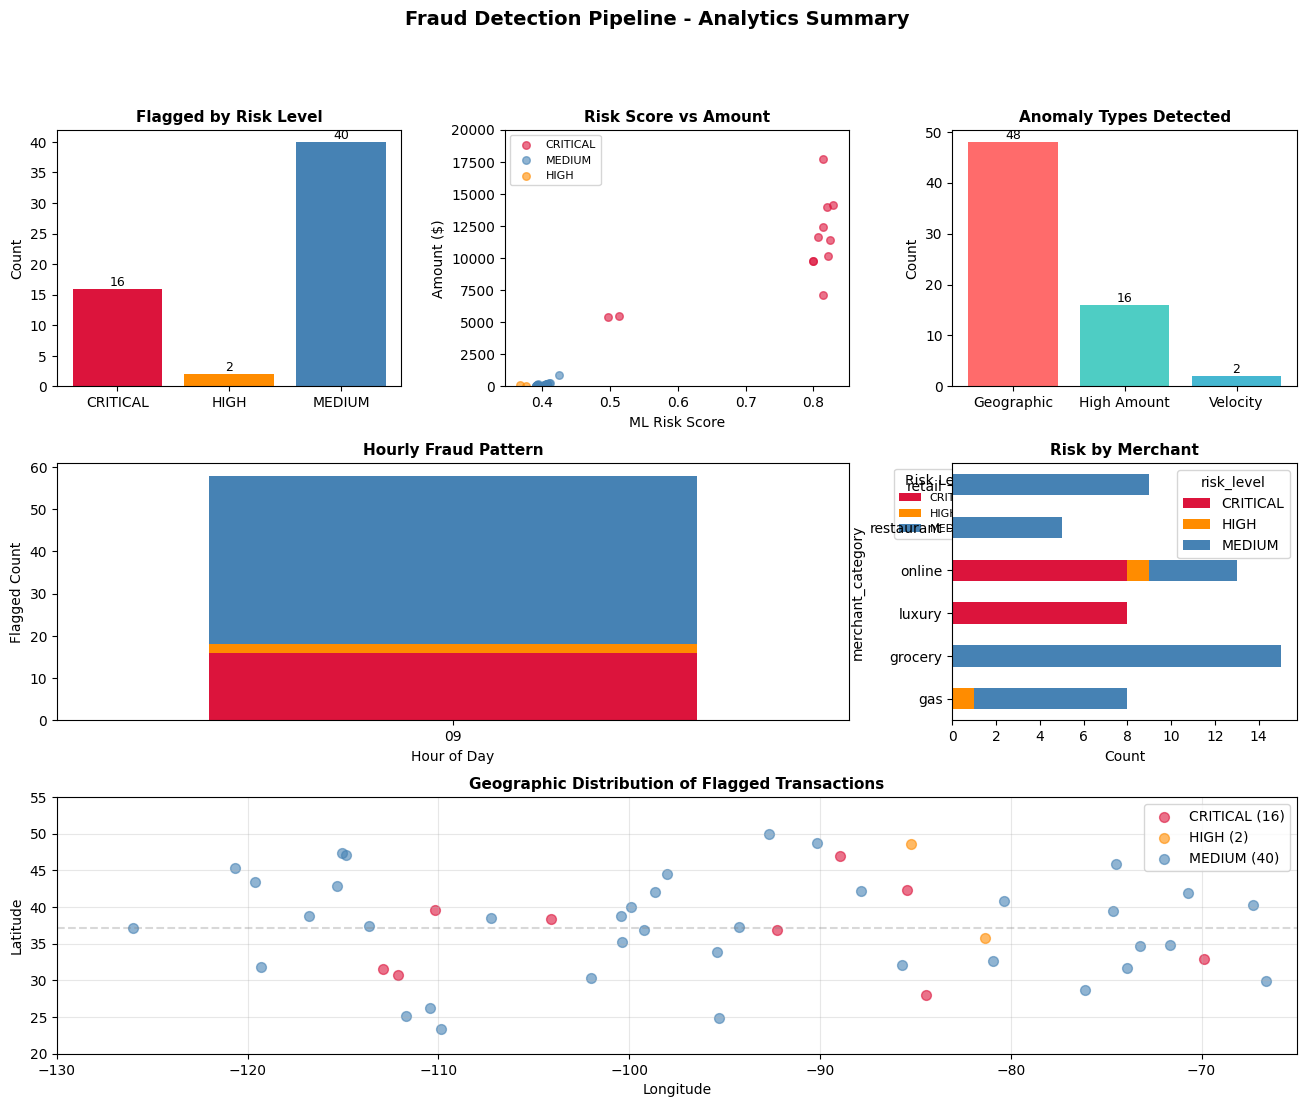


✅ Comprehensive visualization saved to: /content/fraud_pipeline_summary.png

✅ PIPELINE VALIDATION REPORT

🧪 Validation Results:
   ✅ Database Created
   ✅ CSV Export Exists
   ✅ Dashboard Code Saved
   ✅ Flagged Transactions
   ✅ ML Models Trained
   ✅ Tableau Files Ready

📊 Final Statistics:
   Total Transactions Processed: 500
   Total Transactions Flagged: 58
   Flag Rate: 11.60%
   Database Size: 32,768 bytes

🚀 READY FOR DEPLOYMENT

Next Steps:
1. ✅ Pipeline executed - data generated and stored
2. ⏳ Set ngrok token in Cell 12 and run to launch dashboard
3. 📊 Download CSV files for Tableau Public
4. 🔗 Add ngrok URL and Tableau link to your CV

All files are in /content/ directory and ready for use!



In [24]:
# ============================================================
# CELL 14: FINAL VISUALIZATION AND VALIDATION
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Create comprehensive visualization
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Risk Level Distribution (Top Left)
ax1 = fig.add_subplot(gs[0, 0])
if not summary_stats.empty:
    colors = {'CRITICAL': '#DC143C', 'HIGH': '#FF8C00', 'MEDIUM': '#4682B4', 'LOW': '#90EE90'}
    bar_colors = [colors.get(r, 'gray') for r in summary_stats['risk_level']]
    bars = ax1.bar(summary_stats['risk_level'], summary_stats['transaction_count'], color=bar_colors)
    ax1.set_title('Flagged by Risk Level', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Count')
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)

# 2. Amount vs Risk Score Scatter (Top Center)
ax2 = fig.add_subplot(gs[0, 1])
if not df_flagged.empty:
    risk_colors = {'CRITICAL': '#DC143C', 'HIGH': '#FF8C00', 'MEDIUM': '#4682B4', 'LOW': '#90EE90'}
    for risk_level in df_flagged['risk_level'].unique():
        mask = df_flagged['risk_level'] == risk_level
        ax2.scatter(df_flagged[mask]['ml_score'], df_flagged[mask]['amount'],
                   c=risk_colors.get(risk_level, 'gray'), label=risk_level, alpha=0.6, s=30)
    ax2.set_xlabel('ML Risk Score')
    ax2.set_ylabel('Amount ($)')
    ax2.set_title('Risk Score vs Amount', fontsize=11, fontweight='bold')
    ax2.legend(fontsize=8)
    ax2.set_ylim(0, min(20000, df_flagged['amount'].max() * 1.1))

# 3. Anomaly Types (Top Right)
ax3 = fig.add_subplot(gs[0, 2])
if not df_flagged.empty:
    geo_count = int(df_flagged['is_geo_anomaly'].sum())
    amt_count = int(df_flagged['is_amount_anomaly'].sum())
    velocity_count = int((df_flagged['velocity_count'] > CONFIG['velocity_threshold']).sum())

    anomaly_data = [geo_count, amt_count, velocity_count]
    anomaly_labels = ['Geographic', 'High Amount', 'Velocity']
    colors_anom = ['#FF6B6B', '#4ECDC4', '#45B7D1']

    bars = ax3.bar(anomaly_labels, anomaly_data, color=colors_anom)
    ax3.set_title('Anomaly Types Detected', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Count')
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)

# 4. Hourly Pattern (Middle Left - spans 2 columns)
ax4 = fig.add_subplot(gs[1, :2])
if not time_series.empty:
    pivot_time = time_series.pivot_table(
        values='count',
        index='hour',
        columns='risk_level',
        aggfunc='sum',
        fill_value=0
    )
    risk_colors_list = [colors.get(c, 'gray') for c in pivot_time.columns]
    pivot_time.plot(kind='bar', stacked=True, ax=ax4, color=risk_colors_list, width=0.8)
    ax4.set_title('Hourly Fraud Pattern', fontsize=11, fontweight='bold')
    ax4.set_xlabel('Hour of Day')
    ax4.set_ylabel('Flagged Count')
    ax4.legend(title='Risk Level', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax4.tick_params(axis='x', rotation=0)

# 5. Merchant Risk (Middle Right)
ax5 = fig.add_subplot(gs[1, 2])
if not merchant_stats.empty:
    merchant_pivot = merchant_stats.pivot_table(
        values='count',
        index='merchant_category',
        columns='risk_level',
        aggfunc='sum',
        fill_value=0
    )
    merchant_pivot.plot(kind='barh', stacked=True, ax=ax5,
                       color=[colors.get(c, 'gray') for c in merchant_pivot.columns])
    ax5.set_title('Risk by Merchant', fontsize=11, fontweight='bold')
    ax5.set_xlabel('Count')

# 6. Geographic Heatmap (Bottom - spans all columns)
ax6 = fig.add_subplot(gs[2, :])
if not df_flagged.empty and not geo_clusters.empty:
    # Create scatter plot of transactions
    for risk_level in ['CRITICAL', 'HIGH', 'MEDIUM']:
        mask = df_flagged['risk_level'] == risk_level
        if mask.any():
            ax6.scatter(df_flagged[mask]['longitude'], df_flagged[mask]['latitude'],
                       c=risk_colors.get(risk_level), label=f'{risk_level} ({mask.sum()})',
                       alpha=0.6, s=50)

    ax6.set_xlabel('Longitude')
    ax6.set_ylabel('Latitude')
    ax6.set_title('Geographic Distribution of Flagged Transactions', fontsize=11, fontweight='bold')
    ax6.legend(loc='upper right')
    ax6.grid(True, alpha=0.3)

    # Add US map outline approximation
    ax6.set_xlim(-130, -65)
    ax6.set_ylim(20, 55)
    ax6.axhline(y=37.0902, color='gray', linestyle='--', alpha=0.3, label='US Center')

plt.suptitle('Fraud Detection Pipeline - Analytics Summary', fontsize=14, fontweight='bold', y=0.98)
plt.savefig('/content/fraud_pipeline_summary.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✅ Comprehensive visualization saved to: /content/fraud_pipeline_summary.png")

# Final validation report
print("\n" + "=" * 60)
print("✅ PIPELINE VALIDATION REPORT")
print("=" * 60)

validation_checks = {
    "Database Created": os.path.exists(CONFIG['db_path']),
    "CSV Export Exists": os.path.exists(CONFIG['csv_output']),
    "Dashboard Code Saved": os.path.exists('/content/fraud_dashboard.py'),
    "Flagged Transactions": len(df_flagged) > 0,
    "ML Models Trained": iso_forest is not None and rf_clf is not None,
    "Tableau Files Ready": all(os.path.exists(f'/content/{f}') for f in [
        'tableau_flagged_transactions.csv',
        'tableau_risk_summary.csv',
        'tableau_time_series.csv'
    ])
}

print("\n🧪 Validation Results:")
for check, status in validation_checks.items():
    symbol = "✅" if status else "❌"
    print(f"   {symbol} {check}")

# Summary statistics
print(f"\n📊 Final Statistics:")
print(f"   Total Transactions Processed: {processor.processed_count}")
print(f"   Total Transactions Flagged: {processor.flagged_count}")
print(f"   Flag Rate: {(processor.flagged_count/max(processor.processed_count, 1)*100):.2f}%")
print(f"   Database Size: {os.path.getsize(CONFIG['db_path']):,} bytes")

print("\n" + "=" * 60)
print("🚀 READY FOR DEPLOYMENT")
print("=" * 60)
print("""
Next Steps:
1. ✅ Pipeline executed - data generated and stored
2. ⏳ Set ngrok token in Cell 12 and run to launch dashboard
3. 📊 Download CSV files for Tableau Public
4. 🔗 Add ngrok URL and Tableau link to your CV

All files are in /content/ directory and ready for use!
""")

In [25]:
from google.colab import files

# Download a specific file
files.download('/content/fraud_alerts_output.csv')

# Or download multiple files
import os
for filename in os.listdir('/content/'):
    if filename.endswith('.csv') or filename.endswith('.png'):
        print(f"Downloading: {filename}")
        files.download(f'/content/{filename}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: tableau_geo_clusters.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: tableau_risk_summary.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>